In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch.optim import Adam, AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, accuracy_score, roc_curve, auc
from datetime import datetime
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline


MODEL_NAMES = {"biobert": "dmis-lab/biobert-v1.1"}

LABELS = ["Treatment","Diagnosis","Prevention","Mechanism",
          "Transmission","Epidemic Forecasting","Case Report"]

NUM_LABELS = len(LABELS)

MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS = 20

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_gs_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/BC7-LitCovid-Test-GS.csv', sep=',')
train_df   = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/BC7-LitCovid-Train.csv', sep=',')

train_df = train_df.sample(n=10000, random_state=42, replace=False)
test_gs_df = test_gs_df.sample(n=2000, random_state=42, replace=False)

print("Train size:", len(train_df))
print("Test size:", len(test_gs_df))

Train size: 10000
Test size: 2000


In [ ]:
# Dropping pmid and doi columns
test_gs_df.drop(columns=['pmid', 'doi'], inplace=True)
train_df.drop(columns=['pmid', 'doi'], inplace=True)

# Filling any NaNs with empty string ''
test_gs_df.fillna('', inplace=True)
train_df.fillna('', inplace=True)

In [ ]:
class LitCovidDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

        # precompute labels
        self.df["encoded_labels"] = self.df["label"].apply(self.encode_labels)

    # multi label encoding for target labels ([1, 0, 0, 1, 0, 0, 0])
    def encode_labels(self, label_str):
        if pd.isna(label_str):
            return [0] * len(LABELS)

        label_list = [l.strip() for l in str(label_str).split(";")]
        return [1 if label in label_list else 0 for label in LABELS]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        text = f"{row['title']} {row['keywords']} {row['abstract']}"

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(row["encoded_labels"], dtype=torch.float)
        }

In [ ]:
class MultiLabelModel(nn.Module):
    def __init__(self, model_name, freeze_weights):
        super().__init__()

        # load pretrained encoder
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        # classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_LABELS)
        )

        # freeze the encoder weights in baseline model
        if freeze_weights:
            for param in self.encoder.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        # extract the [CLS] token embedding as the sequence representation
        cls_output = outputs.last_hidden_state[:, 0]

        # pass CLS embedding through classifier
        logits = self.classifier(cls_output)
        return logits

In [ ]:
def print_detailed_report(probs, labels, label_names, threshold=0.5):
    # convert probabilities to predictions
    preds = (probs > threshold).astype(int)

    print(classification_report(
        labels,
        preds,
        target_names=label_names,
        ))

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    active = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters:  {total:,}")
    print(f"Active Parameters: {active:,}")
    return total, active

In [ ]:
def evaluate_roc_ovr(probs, y_true, label_names):

    plt.figure(figsize=(8, 6))

    aucs = []

    # compute and plot a ROC curve for each label (One-vs-Rest)
    # each label is treated as binary (that label vs. all other labels)
    for i in range(len(label_names)):
        fpr, tpr, _ = roc_curve(y_true[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        plt.plot(fpr, tpr, label=f"{label_names[i]} (AUC = {roc_auc:.2f})")

    # Macro avg AUC, treats each label equally regardless of class frequency
    macro_auc = np.mean(aucs)
    print(f"Macro-average AUC: {macro_auc:.4f}")

    plt.plot([0, 1], [0, 1], "k--")
    plt.title("One-vs-Rest ROC Curves")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

In [ ]:
def train_model(model_key):
    print(f"\nTraining {model_key}")

    # load tokenizer matching the pretrained model
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAMES[model_key])

    # tokenize train and test splits into PyTorch datasets
    train_dataset = LitCovidDataset(train_df, tokenizer, MAX_LEN)
    test_dataset = LitCovidDataset(test_gs_df, tokenizer, MAX_LEN)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

    # instantiate model and move to GPU
    model = MultiLabelModel(MODEL_NAMES[model_key], freeze_weights=True).to(DEVICE)
    count_parameters(model)

    optimizer = AdamW(model.parameters(), lr=0.00002)

    # combines a sigmoid activation function and Binary Cross-Entropy Loss
    criterion = nn.BCEWithLogitsLoss()

    train_losses = np.zeros(EPOCHS)
    test_losses = np.zeros(EPOCHS)

    # Training loop
    for epoch in range(EPOCHS):
        model.train()

        train_loss = 0
        n_train = 0

        for batch in tqdm(train_loader):
            # move data to GPU
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            # Zero out any previously calculated gradients
            model.zero_grad()

            # Perform a forward pass. This will return logits.
            outputs = model(batch['input_ids'], batch['attention_mask'])

            loss = criterion(outputs, batch['labels'])

            # Perform a backward pass to calculate gradients
            loss.backward()

            # Clip the norm of the gradients to 1.0 to prevent "exploding gradients"
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update parameters and the learning rat
            optimizer.step()

            train_loss += loss.item()*batch['input_ids'].size(0)
            n_train += batch['input_ids'].size(0)

        # Get average train loss
        train_loss = train_loss / n_train

        # Evalaute model at the end of each epoch
        model.eval()

        test_loss = 0
        n_test = 0
        test_preds, test_labels = [], []

        with torch.no_grad():
            for batch in test_loader:
                # move data to GPU
                batch = {k: v.to(DEVICE) for k, v in batch.items()}

                # Compute logits
                logits = model(batch['input_ids'], batch['attention_mask'])

                # Compute loss
                loss = criterion(logits, batch['labels'])
                test_loss += loss.item()*batch['input_ids'].size(0)
                n_test += batch['input_ids'].size(0)

                test_preds.append(logits)
                test_labels.append(batch['labels'])
            test_loss = test_loss / n_test

        # Save losses
        train_losses[epoch] = train_loss
        test_losses[epoch] = test_loss

        print(f'Epoch {epoch+1}/{EPOCHS} \t Train Loss: {train_loss:.4f} \t Test Loss: {test_loss:.4f}')

    # combine all metrics computed over all batches
    test_preds = torch.cat(test_preds)
    test_labels = torch.cat(test_labels)

    probs = torch.sigmoid(test_preds).cpu().numpy()
    y_true = test_labels.cpu().numpy()

    print(f"\nFinal Test Results ({model_key}):")
    print_detailed_report(probs, y_true, LABELS)

    evaluate_roc_ovr(probs, y_true, LABELS)



Training biobert


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Total Parameters:  108,508,935
Active Parameters: 198,663


100%|██████████| 625/625 [00:47<00:00, 13.26it/s]


Epoch 1/20 	 Train Loss: 0.4798 	 Test Loss: 0.3961


...

100%|██████████| 625/625 [00:47<00:00, 13.20it/s]


Epoch 19/20 	 Train Loss: 0.1739 	 Test Loss: 0.1809


100%|██████████| 625/625 [00:47<00:00, 13.23it/s]


Epoch 20/20 	 Train Loss: 0.1723 	 Test Loss: 0.1794

Final Test Results (biobert):
                      precision    recall  f1-score   support

           Treatment       0.84      0.81      0.82       837
           Diagnosis       0.82      0.74      0.78       573
          Prevention       0.88      0.89      0.89       722
           Mechanism       0.93      0.77      0.84       463
        Transmission       1.00      0.02      0.04       105
Epidemic Forecasting       0.73      0.47      0.57        34
         Case Report       0.94      0.83      0.88       164

           micro avg       0.87      0.78      0.82      2898
           macro avg       0.88      0.65      0.69      2898
        weighted avg       0.87      0.78      0.81      2898
         samples avg       0.83      0.80      0.80      2898

Macro-average AUC: 0.9567


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


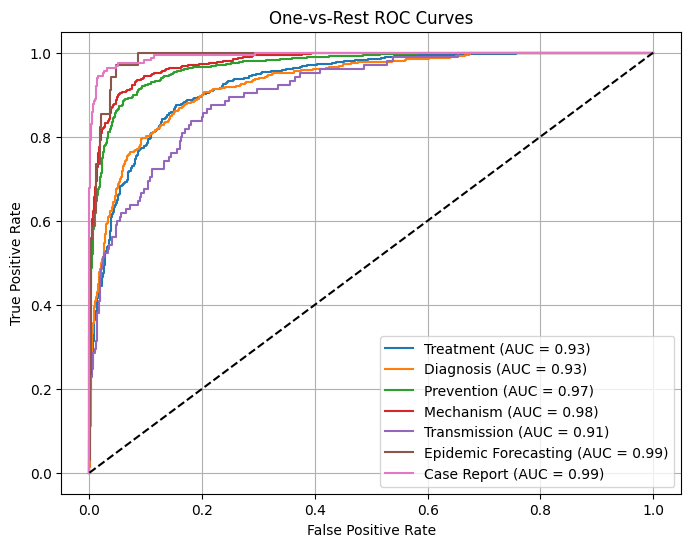

In [ ]:
train_model("biobert")